In [1]:
# ==========================================================
# STEP 1 : IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

import matplotlib.pyplot as plt

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
def load_cmapss(file_path, dataset_name):

    df = pd.read_csv(file_path, sep=r"\s+", header=None)

    columns = ['unit','cycle','op1','op2','op3'] + \
              [f'sensor{i}' for i in range(1,22)]

    df.columns = columns

    df['dataset'] = dataset_name

    print(dataset_name,"shape:",df.shape)

    return df


df1 = load_cmapss("data/train_FD001.txt","FD001")
df2 = load_cmapss("data/train_FD002.txt","FD002")
df3 = load_cmapss("data/train_FD003.txt","FD003")
df4 = load_cmapss("data/train_FD004.txt","FD004")

FD001 shape: (20631, 27)
FD002 shape: (53759, 27)
FD003 shape: (24720, 27)
FD004 shape: (61249, 27)


In [3]:
df = pd.concat([df1,df2,df3,df4],ignore_index=True)

print("Merged Dataset Shape:",df.shape)

df['unit_id'] = df['dataset'] + "_" + df['unit'].astype(str)

print("Total Engines:",df['unit_id'].nunique())

Merged Dataset Shape: (160359, 27)
Total Engines: 709


In [4]:
drop_cols = [
'sensor1',
'sensor5',
'sensor6',
'sensor10',
'sensor16',
'sensor18',
'sensor19'
]

df = df.drop(columns=drop_cols)

print("Remaining Columns:",df.columns)

Remaining Columns: Index(['unit', 'cycle', 'op1', 'op2', 'op3', 'sensor2', 'sensor3', 'sensor4',
       'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13',
       'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21', 'dataset',
       'unit_id'],
      dtype='object')


In [5]:
max_cycle = df.groupby('unit_id')['cycle'].max().reset_index()

max_cycle.columns = ['unit_id','max_cycle']

df = df.merge(max_cycle,on='unit_id')

df['RUL'] = df['max_cycle'] - df['cycle']
df['RUL'] = df['RUL'].clip(upper=125)
df['RUL'] = df['RUL'] / 125.0
df.drop(columns=['max_cycle'],inplace=True)

print("RUL Calculation Completed")
print(df[['unit_id','cycle','RUL']].head())

RUL Calculation Completed
   unit_id  cycle  RUL
0  FD001_1      1  1.0
1  FD001_1      2  1.0
2  FD001_1      3  1.0
3  FD001_1      4  1.0
4  FD001_1      5  1.0


In [6]:
engine_ids = df['unit_id'].unique()

train_engines,val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_df = df[df['unit_id'].isin(train_engines)].copy()
val_df   = df[df['unit_id'].isin(val_engines)].copy()

print("Train engines:",len(train_engines))
print("Validation engines:",len(val_engines))

Train engines: 567
Validation engines: 142


In [7]:
train_df = train_df.sort_values(['unit_id','cycle'])
val_df   = val_df.sort_values(['unit_id','cycle'])

print("Sorting Completed")

Sorting Completed


In [8]:
feature_cols = ['op1','op2','op3'] + \
               [col for col in df.columns if 'sensor' in col]

print("Total Features:",len(feature_cols))
print(feature_cols)

Total Features: 17
['op1', 'op2', 'op3', 'sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21']


In [9]:
scaler = StandardScaler()

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])

val_df[feature_cols] = scaler.transform(val_df[feature_cols])

print("Normalization Completed")

Normalization Completed


In [10]:
def create_sequences(dataframe,seq_length,feature_cols):

    X = []
    y = []

    for unit in dataframe['unit_id'].unique():

        unit_df = dataframe[dataframe['unit_id']==unit]

        data = unit_df[feature_cols].values
        rul  = unit_df['RUL'].values

        for i in range(len(unit_df)-seq_length):

            X.append(data[i:i+seq_length])
            y.append(rul[i+seq_length-1])

    return np.array(X),np.array(y)


SEQ_LENGTH = 30

X_train,y_train = create_sequences(train_df,SEQ_LENGTH,feature_cols)
X_val,y_val     = create_sequences(val_df,SEQ_LENGTH,feature_cols)

print("Rolling Window Created")
print("X_train shape:",X_train.shape)
print("X_val shape:",X_val.shape)

Rolling Window Created
X_train shape: (112309, 30, 17)
X_val shape: (26780, 30, 17)


In [11]:
def evaluate_model(y_true,y_pred,model_name):

    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    mae  = mean_absolute_error(y_true,y_pred)
    r2   = r2_score(y_true,y_pred)

    print("\n",model_name,"Results")
    print("RMSE:",rmse)
    print("MAE :",mae)
    print("R2  :",r2)

In [12]:
n_features = X_train.shape[2]

lstm_model = Sequential([

    LSTM(128, return_sequences=True, input_shape=(SEQ_LENGTH, n_features)),
    Dropout(0.3),

    LSTM(128, return_sequences=True),
    Dropout(0.3),

    LSTM(64, return_sequences=True),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

lstm_model.summary()

C:\Users\cahal\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,249 (1.03 MB)

 Trainable params: 269,249 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_lstm = lstm_model.fit(

    X_train,
    y_train,

    validation_data=(X_val,y_val),

    epochs=50,
    batch_size=128
)

Epoch 1/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 115s 123ms/step - loss: 0.0464 - mae: 0.1635 - val_loss: 0.0347 - val_mae: 0.1549
Epoch 2/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 95s 108ms/step - loss: 0.0254 - mae: 0.1198 - val_loss: 0.0325 - val_mae: 0.1466
Epoch 3/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 97s 110ms/step - loss: 0.0219 - mae: 0.1096 - val_loss: 0.0276 - val_mae: 0.1385
Epoch 4/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 97s 111ms/step - loss: 0.0199 - mae: 0.1033 - val_loss: 0.0270 - val_mae: 0.1334
Epoch 5/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 100s 113ms/step - loss: 0.0186 - mae: 0.0994 - val_loss: 0.0251 - val_mae: 0.1294
Epoch 6/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 99s 113ms/step - loss: 0.0179 - mae: 0.0970 - val_loss: 0.0230 - val_mae: 0.1233
Epoch 7/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 102s 116ms/step - loss: 0.0174 - mae: 0.0952 - val_loss: 0.0214 - val_mae: 0.1224
Epoch 8/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 111s 126ms/step - loss: 0.0165 - mae: 0.0923 - val_loss: 0.0217 - val_mae: 0.1207
Epoch 9/50
878/878 ━━━━━━━━━

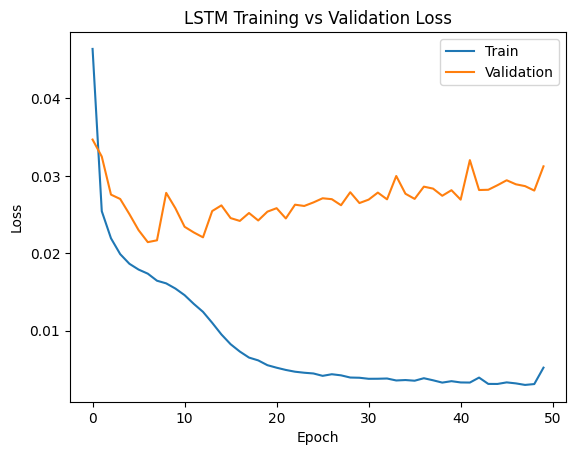

In [14]:
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [15]:
y_pred_lstm = lstm_model.predict(X_val)

evaluate_model(y_val,y_pred_lstm,"LSTM")

837/837 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step

 LSTM Results
RMSE: 0.17669562668473568
MAE : 0.14560409255261028
R2  : 0.7170280181129709


In [16]:
# gru_model = Sequential([

#     GRU(128,return_sequences=True,input_shape=(SEQ_LENGTH,n_features)),
#     Dropout(0.3),

#     GRU(64),

#     Dense(32,activation='relu'),

#     Dense(1)
# ])
gru_model = Sequential([

    GRU(128, return_sequences=True, input_shape=(SEQ_LENGTH, n_features)),
    Dropout(0.3),

    GRU(128, return_sequences=True),
    Dropout(0.3),

    GRU(64, return_sequences=True),
    Dropout(0.3),

    GRU(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

gru_model.summary()

C:\Users\cahal\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 128)        │        56,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 30, 128)        │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 30, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,265 (794.00 KB)

 Trainable params: 203,265 (794.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history_gru = gru_model.fit(

    X_train,
    y_train,

    validation_data=(X_val,y_val),

    epochs=50,
    batch_size=128
)

Epoch 1/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 82s 87ms/step - loss: 0.0414 - mae: 0.1556 - val_loss: 0.0502 - val_mae: 0.1878
Epoch 2/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 149s 170ms/step - loss: 0.0256 - mae: 0.1211 - val_loss: 0.0320 - val_mae: 0.1502
Epoch 3/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 166s 190ms/step - loss: 0.0224 - mae: 0.1117 - val_loss: 0.0311 - val_mae: 0.1469
Epoch 4/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 173s 197ms/step - loss: 0.0207 - mae: 0.1065 - val_loss: 0.0286 - val_mae: 0.1439
Epoch 5/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 177s 201ms/step - loss: 0.0196 - mae: 0.1031 - val_loss: 0.0275 - val_mae: 0.1346
Epoch 6/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 204s 232ms/step - loss: 0.0182 - mae: 0.0986 - val_loss: 0.0237 - val_mae: 0.1268
Epoch 7/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 231s 196ms/step - loss: 0.0172 - mae: 0.0952 - val_loss: 0.0273 - val_mae: 0.1383
Epoch 8/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 176s 200ms/step - loss: 0.0165 - mae: 0.0931 - val_loss: 0.0281 - val_mae: 0.1382
Epoch 9/50
878/878 ━━━━━━━

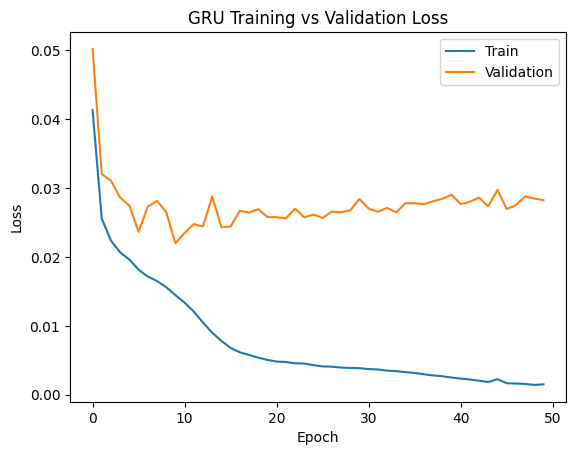

In [18]:
plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])

plt.title("GRU Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [19]:
y_pred_gru = gru_model.predict(X_val)

evaluate_model(y_val,y_pred_gru,"GRU")

837/837 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step

 GRU Results
RMSE: 0.16807178379103263
MAE : 0.13259419708345876
R2  : 0.7439755427913213


In [20]:
lstm_model.save("models/lstm_rul_model.h5")
gru_model.save("models/gru_rul_model.h5")

print("Models saved successfully")

Models saved successfully


FD001 shape: (13096, 27)
FD002 shape: (33991, 27)
FD003 shape: (16596, 27)
FD004 shape: (41214, 27)
X_test shape: (690, 30, 17)
y_test shape: (690,)
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

===== FINAL TEST RMSE =====
LSTM: 0.16716388447484265
GRU : 0.1483940639864291
ENS : 0.14980449877108823


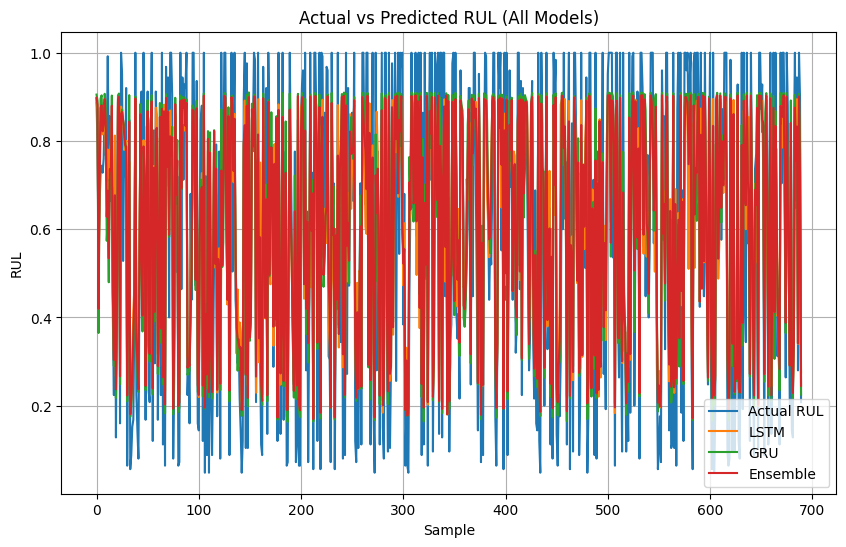

Bias (Ensemble): -0.011980264229359834


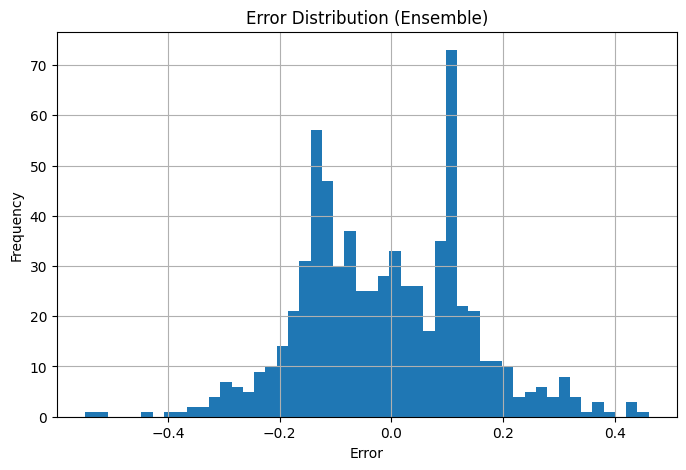


 LSTM (Test) Results
RMSE: 0.16716388447484265
MAE : 0.1375607672606689
R2  : 0.7512263256531594

 GRU (Test) Results
RMSE: 0.1483940639864291
MAE : 0.11874710081193758
R2  : 0.80395644504551

 Ensemble (Test) Results
RMSE: 0.14980449877108823
MAE : 0.12268510727882384
R2  : 0.8002120809883415

===== MODEL COMPARISON =====
      Model      RMSE
0      LSTM  0.167164
1       GRU  0.148394
2  Ensemble  0.149804


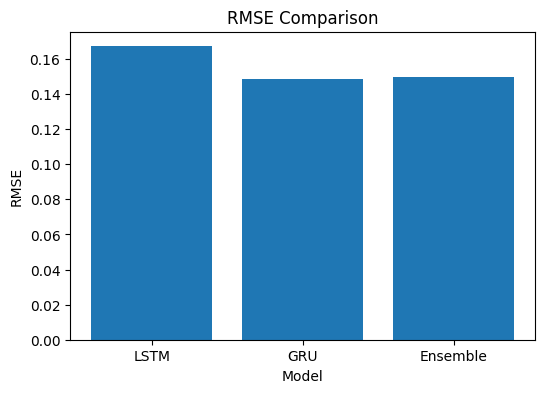


Best Model:
Model         GRU
RMSE     0.148394
Name: 1, dtype: object


In [21]:
# ===============================
# MILESTONE 3 + 4 (FINAL BLOCK)
# ===============================

# -------- LOAD TEST DATA --------
test1 = load_cmapss("data/test_FD001.txt","FD001")
test2 = load_cmapss("data/test_FD002.txt","FD002")
test3 = load_cmapss("data/test_FD003.txt","FD003")
test4 = load_cmapss("data/test_FD004.txt","FD004")

test_df = pd.concat([test1,test2,test3,test4],ignore_index=True)
test_df['unit_id'] = test_df['dataset'] + "_" + test_df['unit'].astype(str)

# -------- PREPROCESS --------
test_df = test_df.drop(columns=drop_cols)
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

# -------- LOAD TRUE RUL --------
rul1 = pd.read_csv("data/RUL_FD001.txt", header=None)
rul2 = pd.read_csv("data/RUL_FD002.txt", header=None)
rul3 = pd.read_csv("data/RUL_FD003.txt", header=None)
rul4 = pd.read_csv("data/RUL_FD004.txt", header=None)

rul_df = pd.concat([rul1,rul2,rul3,rul4],ignore_index=True)
rul_df.columns = ['RUL']

# -------- CREATE TEST DATA --------
X_test = []
y_test = []

rul_values = rul_df['RUL'].values
i = 0

for unit in test_df['unit_id'].unique():
    unit_df = test_df[test_df['unit_id'] == unit]
    data = unit_df[feature_cols].values

    if len(unit_df) >= SEQ_LENGTH:
        X_test.append(data[-SEQ_LENGTH:])
        y_test.append(rul_values[i])

    i += 1

X_test = np.array(X_test)
y_test = np.array(y_test)

# Normalize RUL
y_test = np.clip(y_test, 0, 125) / 125.0

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# -------- PREDICTIONS --------
y_pred_lstm = lstm_model.predict(X_test)
y_pred_gru  = gru_model.predict(X_test)

# -------- ENSEMBLE --------
y_pred_ensemble = (0.4 * y_pred_lstm) + (0.6 * y_pred_gru)

# -------- RMSE --------
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
rmse_gru  = np.sqrt(mean_squared_error(y_test, y_pred_gru))
rmse_ensemble = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))

print("\n===== FINAL TEST RMSE =====")
print("LSTM:", rmse_lstm)
print("GRU :", rmse_gru)
print("ENS :", rmse_ensemble)

# -------- PLOT --------
plt.figure(figsize=(10,6))
plt.plot(y_test, label="Actual RUL")
plt.plot(y_pred_lstm, label="LSTM")
plt.plot(y_pred_gru, label="GRU")
plt.plot(y_pred_ensemble, label="Ensemble")
plt.legend()
plt.title("Actual vs Predicted RUL (All Models)")
plt.xlabel("Sample")
plt.ylabel("RUL")
plt.grid()
plt.show()

# -------- ERROR ANALYSIS (ENSEMBLE BEST PRACTICE) --------
errors = y_test - y_pred_ensemble.flatten()
print("Bias (Ensemble):", np.mean(errors))

plt.figure(figsize=(8,5))
plt.hist(errors, bins=50)
plt.title("Error Distribution (Ensemble)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.grid()
plt.show()

# -------- METRICS --------
evaluate_model(y_test, y_pred_lstm, "LSTM (Test)")
evaluate_model(y_test, y_pred_gru, "GRU (Test)")
evaluate_model(y_test, y_pred_ensemble, "Ensemble (Test)")

# -------- MODEL COMPARISON --------
results = pd.DataFrame({
    "Model": ["LSTM", "GRU", "Ensemble"],
    "RMSE": [rmse_lstm, rmse_gru, rmse_ensemble]
})

print("\n===== MODEL COMPARISON =====")
print(results)

# -------- BAR GRAPH --------
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

# -------- BEST MODEL --------
best_model = results.loc[results["RMSE"].idxmin()]
print("\nBest Model:")
print(best_model)



===== ALERT SUMMARY =====
Status
Healthy     383
Warning     158
Critical    149
Name: count, dtype: int64


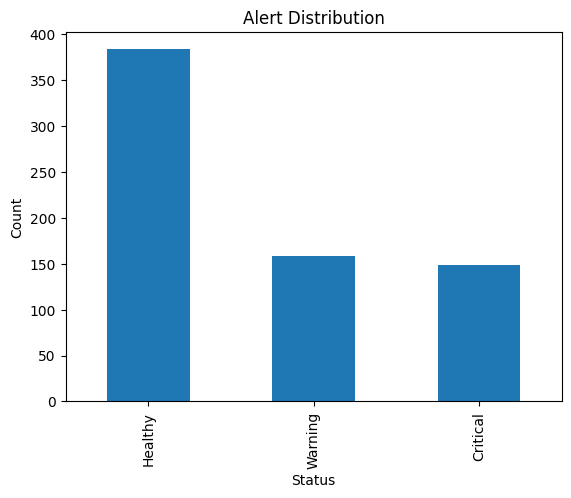


Critical Engines Sample:
    Actual_RUL      LSTM       GRU  Final_Prediction    Status
17       0.224  0.324492  0.289698          0.289698  Critical
19       0.128  0.266177  0.217521          0.217521  Critical
23       0.160  0.293410  0.248881          0.248881  Critical
30       0.064  0.243587  0.209480          0.209480  Critical
33       0.056  0.189465  0.174940          0.174940  Critical


In [22]:


# ===============================
# MILESTONE 4: ALERT SYSTEM
# ===============================

def classify_risk(rul):
    if rul > 0.6:
        return "Healthy"
    elif rul > 0.3:
        return "Warning"
    else:
        return "Critical"

# -------- SELECT BEST MODEL DYNAMICALLY --------

best_model_name = best_model["Model"]

if best_model_name == "LSTM":
    final_predictions = y_pred_lstm
elif best_model_name == "GRU":
    final_predictions = y_pred_gru
else:
    final_predictions = y_pred_ensemble

# -------- ALERT SYSTEM --------
alerts = [classify_risk(r[0]) for r in final_predictions]

alert_df = pd.DataFrame({
    "Actual_RUL": y_test,
    "LSTM": y_pred_lstm.flatten(),
    "GRU": y_pred_gru.flatten(),
   "Final_Prediction": final_predictions.flatten(),
"Status": alerts
})

print("\n===== ALERT SUMMARY =====")
print(alert_df['Status'].value_counts())

# -------- ALERT VISUALIZATION --------
alert_df['Status'].value_counts().plot(kind='bar')
plt.title("Alert Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

# -------- CRITICAL CASES --------
critical_cases = alert_df[alert_df['Status'] == "Critical"]

print("\nCritical Engines Sample:")
print(critical_cases.head())


In [23]:
alert_df.to_csv("outputs/alert_data.csv", index=False)
results.to_csv("outputs/model_results.csv", index=False)